# Testing MG capabilities of CAMB-cs2

In this notebook, I reproduce Figures 3 and 4 from [CFHTLenS: Testing the Laws of Gravity with Tomographic Weak
Lensing and Redshift Space Distortions](https://arxiv.org/pdf/1212.3339)

In [1]:
import numpy as np
from matplotlib import pyplot as plt

import camb

In [2]:
pars = camb.set_params(
    H0=70, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.09, As=2e-9, ns=0.965, halofit_version="mead", WantTransfer=True
)
z = np.linspace(0, 1.2, 100)
pars.set_matter_power(redshifts=z, kmax=2.0)
results = camb.get_results(pars)
fs8_GR = results.get_fsigma8()[::-1]
cltt_GR = results.get_cmb_power_spectra(pars, CMB_unit="muK")["total"][:, 0]
clte_GR = results.get_cmb_power_spectra(pars, CMB_unit="muK")["total"][:, 3]

Note: redshifts have been re-sorted (earliest first)


In [3]:
pars = camb.set_params(
    H0=70, ombh2=0.022, omch2=0.122, mnu=0.06, tau=0.09, As=2e-9, ns=0.965, halofit_version="mead", WantTransfer=True,
    mu0=0.5, Sigma0=0
)
z = np.linspace(0, 1.2, 100)
pars.set_matter_power(redshifts=z, kmax=2.0)
results = camb.get_results(pars)
fs8_MG1 = results.get_fsigma8()[::-1]
cltt_MG1 = results.get_cmb_power_spectra(pars, CMB_unit="muK")["total"][:, 0]
clte_MG1 = results.get_cmb_power_spectra(pars, CMB_unit="muK")["total"][:, 3]

Note: redshifts have been re-sorted (earliest first)


In [4]:
pars = camb.set_params(
    H0=70, ombh2=0.022, omch2=0.122, mnu=0.06, tau=0.09, As=2e-9, ns=0.965, halofit_version="mead", WantTransfer=True,
    mu0=1, Sigma0=0
)
z = np.linspace(0, 1.2, 100)
pars.set_matter_power(redshifts=z, kmax=2.0)
results = camb.get_results(pars)
fs8_MG2 = results.get_fsigma8()[::-1]
cltt_MG2 = results.get_cmb_power_spectra(pars, CMB_unit="muK")["total"][:, 0]
clte_MG2 = results.get_cmb_power_spectra(pars, CMB_unit="muK")["total"][:, 3]

Note: redshifts have been re-sorted (earliest first)


In [5]:
pars = camb.set_params(
    H0=70, ombh2=0.022, omch2=0.122, mnu=0.06, tau=0.09, As=2e-9, ns=0.965, halofit_version="mead", WantTransfer=True,
    mu0=0, Sigma0=-0.5
)
z = np.linspace(0, 1.2, 100)
pars.set_matter_power(redshifts=z, kmax=2.0)
results = camb.get_results(pars)
fs8_MG3 = results.get_fsigma8()[::-1]
cltt_MG3 = results.get_cmb_power_spectra(pars, CMB_unit="muK")["total"][:, 0]
clte_MG3 = results.get_cmb_power_spectra(pars, CMB_unit="muK")["total"][:, 3]

Note: redshifts have been re-sorted (earliest first)


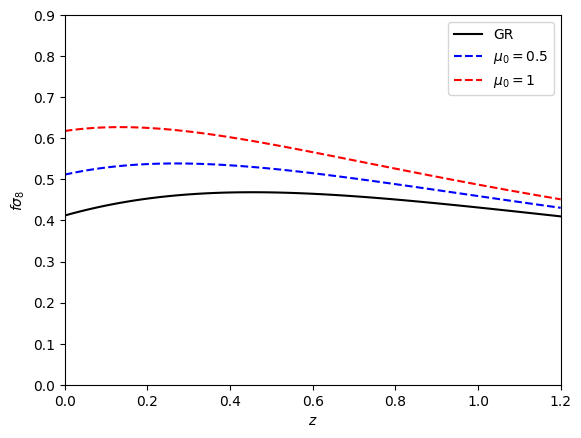

In [13]:
# Figure 3
plt.plot(z, fs8_GR, color="black", ls="-", label="GR")
plt.plot(z, fs8_MG1, color="blue", ls="--", label="$\\mu_0 = 0.5$")
plt.plot(z, fs8_MG2, color="red", ls="--", label="$\\mu_0 = 1$")
plt.xlim([0, 1.2])
plt.ylim([0, 0.9])
plt.xlabel("$z$")
plt.ylabel("$f\\sigma_8$")
plt.legend()

Text(0, 0.5, '$C_\\ell^{TE}$')

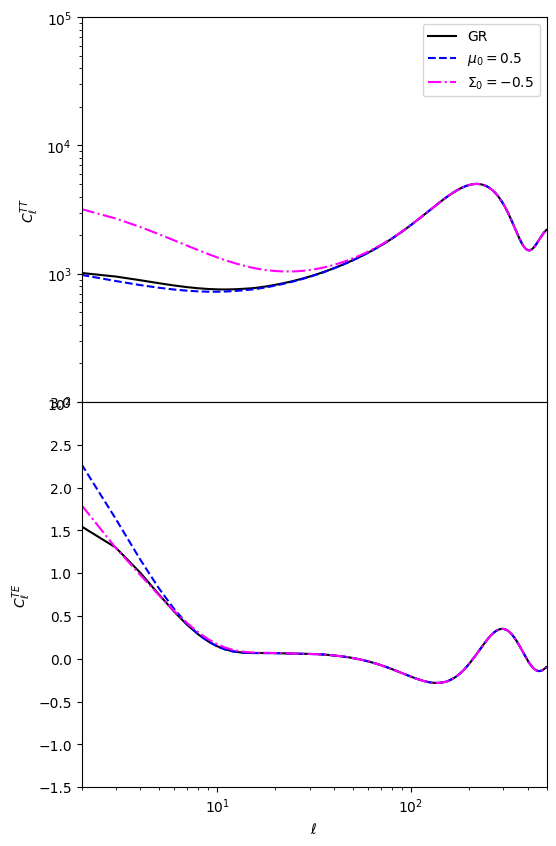

In [23]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(6, 10), gridspec_kw={"hspace": 0})
ell = np.arange(len(cltt_GR))
axs[0].loglog(ell[2:500], cltt_GR[2:500], color="black", ls="-", label="GR")
axs[0].loglog(ell[2:500], cltt_MG1[2:500], color="blue", ls="--", label="$\\mu_0 = 0.5$")
axs[0].loglog(ell[2:500], cltt_MG3[2:500], color="magenta", ls="-.", label="$\\Sigma_0 = -0.5$")
axs[1].semilogx(ell[2:500], clte_GR[2:500]/ell[2:500], color="black", ls="-")
axs[1].semilogx(ell[2:500], clte_MG1[2:500]/ell[2:500], color="blue", ls="--")
axs[1].semilogx(ell[2:500], clte_MG3[2:500]/ell[2:500], color="magenta", ls="-.")
axs[1].set_xlim([2, 500])
axs[0].set_ylim([1e2, 1e5])
axs[1].set_ylim([-1.5, 3])
axs[0].legend()
axs[1].set_xlabel("$\\ell$")
axs[0].set_ylabel("$C_\\ell^{TT}$")
axs[1].set_ylabel("$C_\\ell^{TE}$")